# Gradient Boosting: XGBoost and LightGBM

## Overview

Gradient boosting builds an ensemble sequentially — each new tree corrects the residual errors of the previous ones. It is consistently one of the highest-performing methods on structured tabular data.

**XGBoost vs. LightGBM:**

| Feature | XGBoost | LightGBM |
|---|---|---|
| Tree growth | Level-wise | Leaf-wise (faster, may overfit on small data) |
| Speed | Fast | Very fast (10–20× on large datasets) |
| Memory | Moderate | Low (histogram-based binning) |
| Categorical features | Requires encoding | Native support |
| Typical sweet spot | n < 100k | n > 100k |
| R package | `xgboost` | `lightgbm` |

**In practice:** Start with XGBoost on smaller datasets (< 100k rows). Move to LightGBM if training time becomes a bottleneck. Both are tuned similarly.

**Key hyperparameters:**

| Parameter | XGBoost | LightGBM | Controls |
|---|---|---|---|
| Number of trees | `nrounds` | `num_iterations` | More trees = slower; stop early |
| Learning rate | `eta` | `learning_rate` | Lower = more trees needed but better generalisation |
| Tree depth | `max_depth` | `max_depth` / `num_leaves` | Complexity; risk of overfitting |
| Subsampling | `subsample` | `bagging_fraction` | Row subsampling; reduces variance |
| Feature fraction | `colsample_bytree` | `feature_fraction` | Column subsampling |
| L1 regularisation | `alpha` | `lambda_l1` | Sparsity |
| L2 regularisation | `lambda` | `lambda_l2` | Shrinkage |

---

## Setup

In [3]:
library(tidyverse)
library(ggplot2)
library(xgboost)      # gradient boosting
library(lightgbm)     # fast gradient boosting
library(yardstick)
library(patchwork)

set.seed(42)

n <- 800
gb_data <- tibble(
  nitrate     = rnorm(n, 3, 1.2),
  water_qual  = rnorm(n, 6, 1.5),
  distance_km = rexp(n, 0.4),
  elevation   = rnorm(n, 200, 80),
  slope_pct   = abs(rnorm(n, 10, 5)),
  habitat_ref = as.integer(sample(c("reference","restored","degraded"), n,
                              replace=TRUE, prob=c(.35,.35,.30)) == "reference"),
  habitat_deg = as.integer(sample(c("reference","restored","degraded"), n,
                              replace=TRUE, prob=c(.35,.35,.30)) == "degraded"),
  log_odds    = -1 + 0.6*water_qual - 0.7*nitrate - 0.3*distance_km +
                0.8*habitat_ref - 0.9*habitat_deg,
  label       = rbinom(n, 1, plogis(log_odds))  # 0/1 for XGBoost/LightGBM
)

feature_cols <- c("nitrate","water_qual","distance_km","elevation",
                  "slope_pct","habitat_ref","habitat_deg")

train_idx <- sample(n, 600)
X_train   <- as.matrix(gb_data[train_idx,  feature_cols])
X_test    <- as.matrix(gb_data[-train_idx, feature_cols])
y_train   <- gb_data$label[train_idx]
y_test    <- gb_data$label[-train_idx]

cat(sprintf("Train: %d | Test: %d | Prevalence: %.1f%%\n",
            length(y_train), length(y_test), mean(y_train)*100))

Warning message:
"package 'lightgbm' was built under R version 4.4.3"


Warning message:
"package 'yardstick' was built under R version 4.4.3"

Attaching package: 'yardstick'


The following object is masked from 'package:readr':

    spec


Warning message:
"package 'patchwork' was built under R version 4.4.3"


Train: 600 | Test: 200 | Prevalence: 42.0%


---

## XGBoost

In [6]:
# ── DMatrix: XGBoost's native data format ────────────────────────────────────
dtrain <- xgboost::xgb.DMatrix(X_train, label = y_train)
dtest  <- xgboost::xgb.DMatrix(X_test,  label = y_test)

# ── Parameters ────────────────────────────────────────────────────────────────
xgb_params <- list(
  booster          = "gbtree",
  objective        = "binary:logistic",
  eval_metric      = "auc",
  eta              = 0.05,
  max_depth        = 4,
  subsample        = 0.8,
  colsample_bytree = 0.8,
  min_child_weight = 5,
  lambda           = 1,
  alpha            = 0
)

# ── Fit with early stopping ───────────────────────────────────────────────────
xgb_cv <- xgboost::xgb.cv(
  params                = xgb_params,
  data                  = dtrain,
  nrounds               = 1000,
  nfold                 = 5,
  early_stopping_rounds = 50,
  verbose               = FALSE,
  seed                  = 42
)
best_nrounds <- if (!is.null(xgb_cv$best_iteration) && length(xgb_cv$best_iteration) > 0) {
  xgb_cv$best_iteration
} else {
  nrow(xgb_cv$evaluation_log)  # use all rounds if early stopping never fired
}
cat(sprintf("Best nrounds: %d\n", best_nrounds))

xgb_fit <- xgboost::xgb.train(
  params  = xgb_params,
  data    = dtrain,
  nrounds = best_nrounds,
  verbose = 0
)

# ── Predict ───────────────────────────────────────────────────────────────────
xgb_probs <- predict(xgb_fit, dtest)
xgb_preds <- tibble(
  truth        = factor(y_test, levels = c(0, 1), labels = c("absent", "present")),
  prob_present = xgb_probs,
  pred_class   = factor(ifelse(xgb_probs >= 0.5, "present", "absent"),
                        levels = c("absent", "present"))
)
cat("\nXGBoost Test Metrics:\n")
yardstick::metrics(xgb_preds, truth = truth, estimate = pred_class) %>% print()
yardstick::roc_auc(xgb_preds, truth = truth, prob_present,
                   event_level = "second") %>% print()

Warning message in check.deprecation(deprecated_cv_params, match.call(), ...):
"Passed invalid function arguments: seed. These should be passed as a list to argument 'params'. Conversion from argument to 'params' entry will be done automatically, but this behavior will become an error in a future version."


Best nrounds: 113

XGBoost Test Metrics:
# A tibble: 2 × 3
  .metric  .estimator .estimate
  <chr>    <chr>          <dbl>
1 accuracy binary         0.735
2 kap      binary         0.465
# A tibble: 1 × 3
  .metric .estimator .estimate
  <chr>   <chr>          <dbl>
1 roc_auc binary         0.814


---

## LightGBM

In [7]:
# ── LightGBM Dataset ─────────────────────────────────────────────────────────
lgb_train <- lightgbm::lgb.Dataset(
  X_train, label=y_train,
  categorical_feature=c()   # specify categorical columns by index if any
)
lgb_test  <- lightgbm::lgb.Dataset.create.valid(lgb_train, X_test, label=y_test)

# ── Parameters ────────────────────────────────────────────────────────────────
lgb_params <- list(
  objective         = "binary",
  metric            = "auc",
  learning_rate     = 0.05,
  num_leaves        = 31,     # LightGBM uses num_leaves instead of max_depth
                               # 2^max_depth is the theoretical max; keep < 2^max_depth
  feature_fraction  = 0.8,
  bagging_fraction  = 0.8,
  bagging_freq      = 5,
  min_data_in_leaf  = 10,
  lambda_l1         = 0,
  lambda_l2         = 1,
  verbose           = -1
)

lgb_fit <- lightgbm::lgb.train(
  params         = lgb_params,
  data           = lgb_train,
  nrounds        = 1000,
  valids         = list(test=lgb_test),
  early_stopping_rounds = 50,
  verbose        = -1
)
cat(sprintf("LightGBM best iteration: %d\n", lgb_fit$best_iter))

# Predict
lgb_probs <- predict(lgb_fit, X_test)
lgb_preds <- tibble(
  truth        = factor(y_test, levels=c(0,1), labels=c("absent","present")),
  prob_present = lgb_probs,
  pred_class   = factor(ifelse(lgb_probs>=0.5, "present","absent"),
                        levels=c("absent","present"))
)
cat("\nLightGBM Test Metrics:\n")
yardstick::metrics(lgb_preds, truth=truth, estimate=pred_class) %>% print()
yardstick::roc_auc(lgb_preds, truth=truth, prob_present,
                   event_level="second") %>% print()

LightGBM best iteration: 20

LightGBM Test Metrics:
# A tibble: 2 × 3
  .metric  .estimator .estimate
  <chr>    <chr>          <dbl>
1 accuracy binary         0.645
2 kap      binary         0.276
# A tibble: 1 × 3
  .metric .estimator .estimate
  <chr>   <chr>          <dbl>
1 roc_auc binary         0.813


---

## Feature Importance Comparison

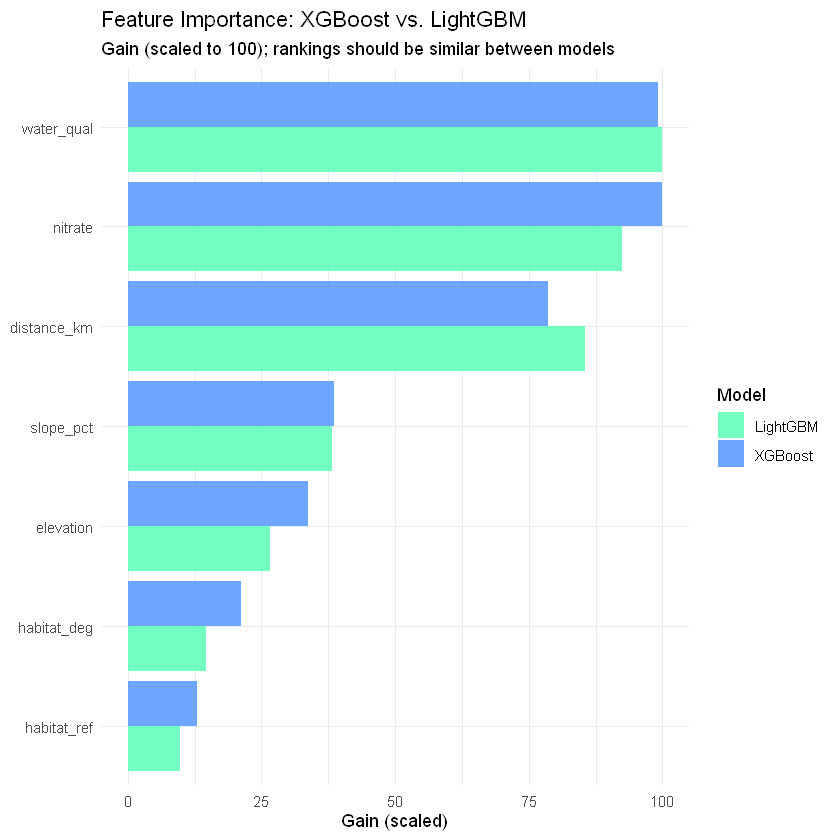

In [8]:
# XGBoost importance (gain: total improvement from splits using the feature)
xgb_vi <- xgboost::xgb.importance(model=xgb_fit, feature_names=feature_cols) %>%
  as_tibble() %>%
  mutate(model="XGBoost")

# LightGBM importance
lgb_vi <- lightgbm::lgb.importance(lgb_fit) %>%
  as_tibble() %>%
  rename(Feature=Feature, Gain=Gain) %>%
  mutate(model="LightGBM")

vi_combined <- bind_rows(
  xgb_vi %>% select(Feature, Gain, model),
  lgb_vi  %>% select(Feature, Gain, model)
) %>%
  group_by(model) %>%
  mutate(Gain_scaled = Gain / max(Gain) * 100) %>%
  ungroup()

ggplot(vi_combined,
       aes(x=Gain_scaled,
           y=reorder(Feature, Gain_scaled),
           fill=model)) +
  geom_col(position="dodge", alpha=0.8) +
  scale_fill_manual(values=c(XGBoost="#4a8fff", LightGBM="#4fffb0")) +
  labs(title="Feature Importance: XGBoost vs. LightGBM",
       subtitle="Gain (scaled to 100); rankings should be similar between models",
       x="Gain (scaled)", y=NULL, fill="Model") +
  theme_minimal()

---

## Common Pitfalls

**1. Not using early stopping**  
Without early stopping, gradient boosting will overfit as `nrounds` increases. Always use cross-validation or a validation set with `early_stopping_rounds`. The number of trees is a regularisation parameter, not a fixed choice.

**2. Setting a high learning rate with few trees**  
A high `eta` (>0.1) makes learning fast but usually produces a worse model than a low `eta` (0.01–0.05) with more trees (found via early stopping). Lower learning rate + more trees is almost always better given enough time.

**3. Using LightGBM's `num_leaves` without understanding it**  
LightGBM grows trees leaf-wise rather than level-wise. `num_leaves` controls complexity directly — a model with `num_leaves=127` is far more complex than `max_depth=7` (2^7=128 leaves, but leaf-wise growth often concentrates on a few branches). On small datasets (n < 10k), reduce `num_leaves` to avoid overfitting.

**4. Using gain-based importance as a definitive ranking**  
Gain importance in XGBoost and LightGBM is biased toward features with many possible split points. Use SHAP values for a more reliable and interpretable importance ranking — see `shap_explainability.ipynb`.

**5. Not tuning regularisation parameters alongside tree parameters**  
Most practitioners tune `max_depth`, `eta`, and `nrounds` but forget `subsample`, `colsample_bytree`, `lambda`, and `alpha`. Subsampling and regularisation are critical for avoiding overfitting on small or noisy datasets. Tune them together using a grid or random search.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*